# Scientific LLM Fine-Tuning: Tokenizer Analysis

This notebook analyzes the processed instruction dataset using the tokenizer of the model selected for fine-tuning.

The analysis will:

- apply the model's chat template,
- calculate sequence lengths,
- compare training, validation, and test splits,
- estimate truncation at candidate context lengths,
- inspect unusually long examples,
- and recommend an appropriate `max_seq_length`.

**Author:** Milad Saeedi

## 1  Title, imports, and configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_from_disk
from transformers import AutoTokenizer


# Reproducibility
SEED = 42


# Model used in the fine-tuning notebook
MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"


# Processed dataset created in notebook 01
DATASET_PATH = Path(
    "../data/processed/scientific_llm_dataset"
)


# Candidate context lengths to evaluate
CANDIDATE_LENGTHS = [
    256,
    512,
    768,
    1024,
    1536,
    2048,
]


print("Model:", MODEL_NAME)
print("Dataset path:", DATASET_PATH.resolve())

Model: HuggingFaceTB/SmolLM2-360M-Instruct
Dataset path: /Users/miladsaeedi/Desktop/Daily_Work_load/LLM_Hug_face/LLM_Course_projects/Project2/data/processed/scientific_llm_dataset


## 2. Load the Processed Dataset

Load the train, validation, and test splits created in the dataset-preparation notebook and verify their structure.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH.resolve()}\n"
        "Run 01_dataset_creation.ipynb first."
    )

In [3]:
dataset = load_from_disk(
    str(DATASET_PATH)
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 1260
    })
    validation: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
    test: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages'],
        num_rows: 158
    })
})

In [4]:
EXPECTED_SPLITS = {
    "train",
    "validation",
    "test",
}

available_splits = set(dataset.keys())

missing_splits = EXPECTED_SPLITS - available_splits

if missing_splits:
    raise ValueError(
        f"Missing dataset splits: {sorted(missing_splits)}"
    )

print("All expected splits are available.")

All expected splits are available.


In [5]:
REQUIRED_COLUMNS = {
    "id",
    "category",
    "task",
    "difficulty",
    "messages",
}

for split_name, split_dataset in dataset.items():
    missing_columns = (
        REQUIRED_COLUMNS
        - set(split_dataset.column_names)
    )

    if missing_columns:
        raise ValueError(
            f"{split_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    print(
        f"{split_name:<10} "
        f"{len(split_dataset):>5} examples"
    )

train       1260 examples
validation   158 examples
test         158 examples


In [6]:
total_examples = sum(
    len(split_dataset)
    for split_dataset in dataset.values()
)

print("\nTotal examples:", total_examples)


Total examples: 1576


In [7]:
sample = dataset["train"][0]

print("ID:", sample["id"])
print("Category:", sample["category"])
print("Task:", sample["task"])
print("Difficulty:", sample["difficulty"])

print("\nMessages:")

for message in sample["messages"]:
    print(f"\n{message['role'].upper()}:")
    print(message["content"])

ID: researchgpt-00001
Category: Air Pollution
Task: scientific_question_answering
Difficulty: intermediate

Messages:

SYSTEM:
You are ResearchGPT, a scientific research assistant.

USER:
Why must spatial autocorrelation be considered in air pollution studies?

ASSISTANT:
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.


In [8]:
for split_name, split_dataset in dataset.items():
    for index, example in enumerate(split_dataset):
        messages = example["messages"]

        roles = [
            message["role"]
            for message in messages
        ]

        if roles != [
            "system",
            "user",
            "assistant",
        ]:
            raise ValueError(
                f"Invalid roles in {split_name}, "
                f"example {index}: {roles}"
            )

print("All examples have valid system-user-assistant messages.")

All examples have valid system-user-assistant messages.


## 3. Load and Inspect the Tokenizer

Load the tokenizer used by the fine-tuning model and inspect its chat template, special tokens, padding configuration, and supported context length.

In [9]:
from transformers import AutoConfig, AutoTokenizer

In [10]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
)

model_config = AutoConfig.from_pretrained(
    MODEL_NAME,
)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [11]:
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Vocabulary size:", len(tokenizer))
print("Fast tokenizer:", tokenizer.is_fast)
print("Tokenizer model_max_length:", tokenizer.model_max_length)

Tokenizer class: GPT2TokenizerFast
Vocabulary size: 49152
Fast tokenizer: True
Tokenizer model_max_length: 8192


In [12]:
configured_context_length = getattr(
    model_config,
    "max_position_embeddings",
    None,
)

print(
    "Model max_position_embeddings:",
    configured_context_length,
)

Model max_position_embeddings: 8192


In [13]:
special_token_summary = {
    "bos_token": tokenizer.bos_token,
    "bos_token_id": tokenizer.bos_token_id,
    "eos_token": tokenizer.eos_token,
    "eos_token_id": tokenizer.eos_token_id,
    "pad_token": tokenizer.pad_token,
    "pad_token_id": tokenizer.pad_token_id,
    "unk_token": tokenizer.unk_token,
    "unk_token_id": tokenizer.unk_token_id,
}

special_token_summary

{'bos_token': '<|im_start|>',
 'bos_token_id': 1,
 'eos_token': '<|im_end|>',
 'eos_token_id': 2,
 'pad_token': '<|im_end|>',
 'pad_token_id': 2,
 'unk_token': '<|endoftext|>',
 'unk_token_id': 0}

In [14]:
tokenizer.special_tokens_map

{'bos_token': '<|im_start|>',
 'eos_token': '<|im_end|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '<|im_end|>',
 'additional_special_tokens': ['<|im_start|>', '<|im_end|>']}

In [15]:
if tokenizer.pad_token is None:
    if tokenizer.eos_token is None:
        raise ValueError(
            "The tokenizer has neither a padding token nor an EOS token."
        )

    tokenizer.pad_token = tokenizer.eos_token

    print(
        "No padding token was defined. "
        "Using the EOS token for padding."
    )
else:
    print(
        "Existing padding token:",
        repr(tokenizer.pad_token),
    )

Existing padding token: '<|im_end|>'


In [16]:
print("Padding token:", repr(tokenizer.pad_token))
print("Padding token ID:", tokenizer.pad_token_id)

Padding token: '<|im_end|>'
Padding token ID: 2


In [17]:
tokenizer.padding_side = "right"

print("Padding side:", tokenizer.padding_side)

Padding side: right


In [18]:
if tokenizer.chat_template is None:
    raise ValueError(
        f"{MODEL_NAME} does not provide a chat template."
    )

print("A chat template is available.")

A chat template is available.


In [19]:
print(tokenizer.chat_template)

{% for message in messages %}{% if loop.first and messages[0]['role'] != 'system' %}{{ '<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
' }}{% endif %}{{'<|im_start|>' + message['role'] + '
' + message['content'] + '<|im_end|>' + '
'}}{% endfor %}{% if add_generation_prompt %}{{ '<|im_start|>assistant
' }}{% endif %}


In [20]:
sample_messages = dataset["train"][0]["messages"]

formatted_sample = tokenizer.apply_chat_template(
    sample_messages,
    tokenize=False,
    add_generation_prompt=False,
)

print(formatted_sample)

<|im_start|>system
You are ResearchGPT, a scientific research assistant.<|im_end|>
<|im_start|>user
Why must spatial autocorrelation be considered in air pollution studies?<|im_end|>
<|im_start|>assistant
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.<|im_end|>



In [21]:
sample_token_ids = tokenizer.apply_chat_template(
    sample_messages,
    tokenize=True,
    add_generation_prompt=False,
)

print("Number of tokens:", len(sample_token_ids))
print("First 20 token IDs:", sample_token_ids[:20])

Number of tokens: 73
First 20 token IDs: [1, 9690, 198, 2683, 359, 2904, 48474, 28, 253, 3097, 1151, 11173, 30, 2, 198, 1, 4093, 198, 4898, 1251]


In [22]:
decoded_sample = tokenizer.decode(
    sample_token_ids,
    skip_special_tokens=False,
)

print(decoded_sample)

<|im_start|>system
You are ResearchGPT, a scientific research assistant.<|im_end|>
<|im_start|>user
Why must spatial autocorrelation be considered in air pollution studies?<|im_end|>
<|im_start|>assistant
Air pollution measurements collected near one another often resemble each other because they share emission sources and meteorological conditions. Accounting for this dependence prevents underestimated uncertainty and overly optimistic model evaluation.<|im_end|>



## 4. Calculate Sequence Lengths

Apply the model’s chat template to every example and calculate the complete sequence length without padding or truncation.

In [23]:
def calculate_token_length(example):
    """
    Apply the model chat template and return the full token count.
    """

    token_ids = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=True,
        add_generation_prompt=False,
    )

    return {
        "token_length": len(token_ids),
    }

In [24]:
dataset_with_lengths = dataset.map(
    calculate_token_length,
    desc="Calculating token lengths",
)

In [25]:
dataset_with_lengths

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages', 'token_length'],
        num_rows: 1260
    })
    validation: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages', 'token_length'],
        num_rows: 158
    })
    test: Dataset({
        features: ['id', 'category', 'task', 'difficulty', 'messages', 'token_length'],
        num_rows: 158
    })
})

In [26]:
for split_name in ["train", "validation", "test"]:
    print(f"\n{split_name.upper()}")

    for example in dataset_with_lengths[split_name].select(
        range(min(3, len(dataset_with_lengths[split_name])))
    ):
        print(
            example["id"],
            example["task"],
            example["token_length"],
        )


TRAIN
researchgpt-00001 scientific_question_answering 73
researchgpt-00002 scientific_question_answering 78
researchgpt-00003 scientific_question_answering 70

VALIDATION
researchgpt-00005 scientific_question_answering 60
researchgpt-00021 scientific_question_answering 72
researchgpt-00026 scientific_question_answering 77

TEST
researchgpt-00013 scientific_question_answering 73
researchgpt-00016 scientific_question_answering 78
researchgpt-00027 scientific_question_answering 79


In [27]:
length_records = []

for split_name, split_dataset in dataset_with_lengths.items():
    for example in split_dataset:
        length_records.append(
            {
                "id": example["id"],
                "split": split_name,
                "category": example["category"],
                "task": example["task"],
                "difficulty": example["difficulty"],
                "token_length": example["token_length"],
            }
        )

length_df = pd.DataFrame(length_records)

length_df.head()

,id,split,category,task,difficulty,token_length
0,researchgpt-00001,train,Air Pollution,scientific_question_answering,intermediate,73
1,researchgpt-00002,train,Air Pollution,scientific_question_answering,intermediate,78
2,researchgpt-00003,train,Air Pollution,scientific_question_answering,intermediate,70
3,researchgpt-00004,train,Air Pollution,scientific_question_answering,intermediate,83
4,researchgpt-00006,train,Air Pollution,scientific_question_answering,intermediate,74


In [28]:
print("Rows in length table:", len(length_df))
print("Total dataset examples:", total_examples)

assert len(length_df) == total_examples

Rows in length table: 1576
Total dataset examples: 1576


In [29]:
length_df["token_length"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
).round(2)

count    1576.00
mean      111.72
std        53.23
min        47.00
50%        96.00
75%       111.00
90%       211.50
95%       223.00
99%       253.25
max       500.00
Name: token_length, dtype: float64

In [30]:
longest_examples = (
    length_df
    .sort_values(
        "token_length",
        ascending=False,
    )
    .head(20)
)

longest_examples

,id,split,category,task,difficulty,token_length
1222,researchgpt-01529,train,Air Pollution,code_generation,intermediate,500
1184,researchgpt-01480,train,Geospatial Machine Learning,code_generation,advanced,411
1191,researchgpt-01489,train,Air Pollution,code_generation,intermediate,375
1233,researchgpt-01543,train,Geospatial Machine Learning,code_generation,intermediate,351
1218,researchgpt-01525,train,Computer Vision & LLMs,code_generation,intermediate,341
1411,researchgpt-01509,validation,Air Pollution,code_generation,intermediate,338
1213,researchgpt-01519,train,Air Pollution,code_generation,intermediate,312
1211,researchgpt-01517,train,Machine Learning,code_generation,intermediate,298
202,researchgpt-00257,train,Geospatial Machine Learning,concept_explanation,intermediate,294
1220,researchgpt-01527,train,Machine Learning,code_generation,intermediate,294


## 5. Visualize Sequence-Length Distributions

Examine the overall token-length distribution and compare the train, validation, and test splits.

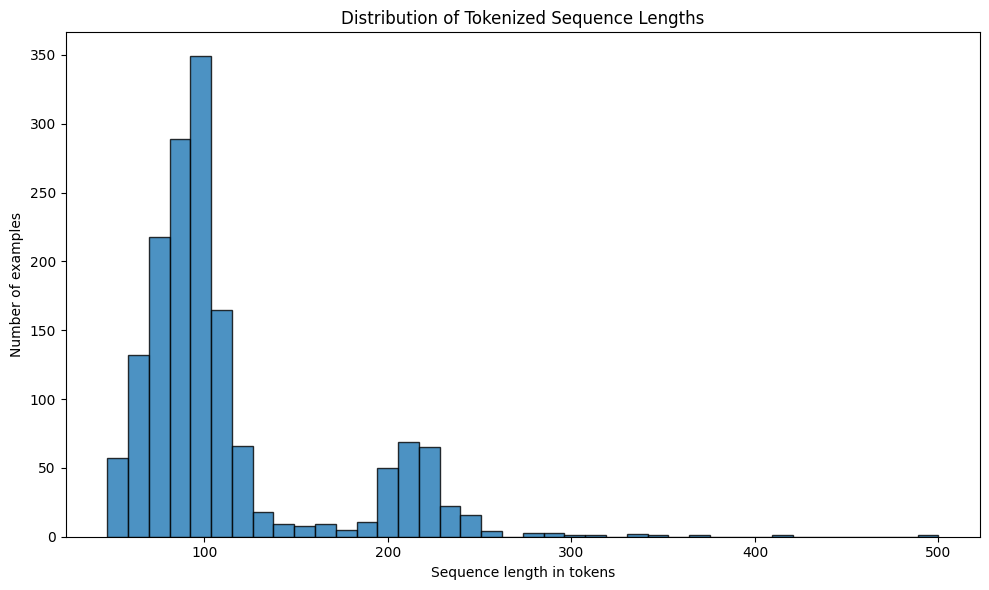

In [31]:
plt.figure(figsize=(10, 6))

plt.hist(
    length_df["token_length"],
    bins=40,
    edgecolor="black",
    alpha=0.8,
)

plt.xlabel("Sequence length in tokens")
plt.ylabel("Number of examples")
plt.title("Distribution of Tokenized Sequence Lengths")
plt.tight_layout()
plt.show()

In [32]:
percentiles = {
    "Median": length_df["token_length"].quantile(0.50),
    "90th percentile": length_df["token_length"].quantile(0.90),
    "95th percentile": length_df["token_length"].quantile(0.95),
    "99th percentile": length_df["token_length"].quantile(0.99),
}

percentiles

{'Median': np.float64(96.0),
 '90th percentile': np.float64(211.5),
 '95th percentile': np.float64(223.0),
 '99th percentile': np.float64(253.25)}

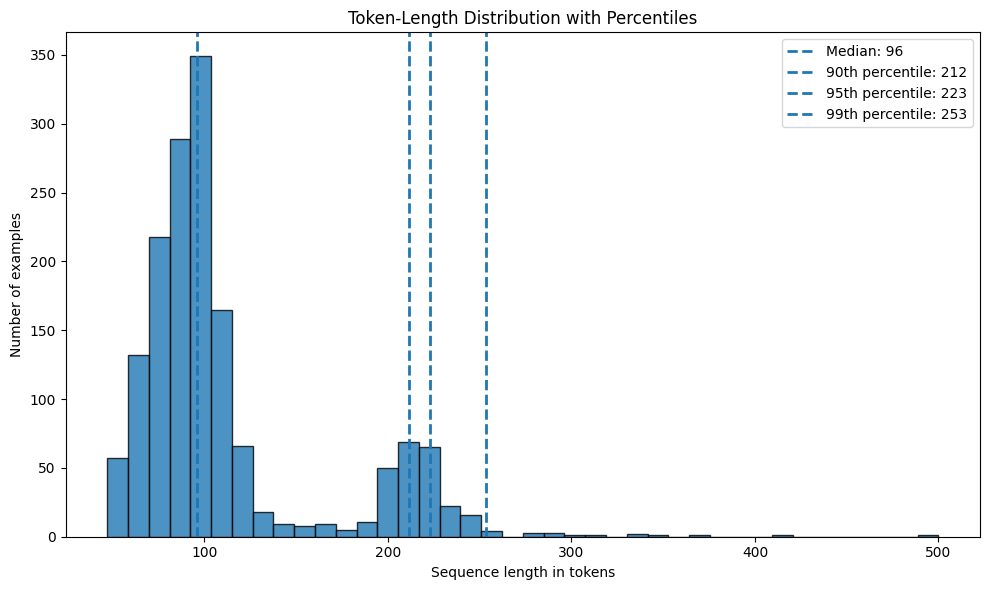

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(
    length_df["token_length"],
    bins=40,
    edgecolor="black",
    alpha=0.8,
)

for label, value in percentiles.items():
    plt.axvline(
        value,
        linestyle="--",
        linewidth=2,
        label=f"{label}: {value:.0f}",
    )

plt.xlabel("Sequence length in tokens")
plt.ylabel("Number of examples")
plt.title("Token-Length Distribution with Percentiles")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
split_length_summary = (
    length_df.groupby("split")["token_length"]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
        ]
    )
    .round(2)
)

split_length_summary

,count,mean,std,min,50%,90%,95%,99%,max
split,,,,,,,,,
test,158.0,110.58,49.57,51.0,97.0,210.6,217.60,233.86,238.0
train,1260.0,111.80,53.72,47.0,95.0,212.0,224.00,254.87,500.0
validation,158.0,112.21,53.15,51.0,94.5,208.6,220.15,267.75,338.0


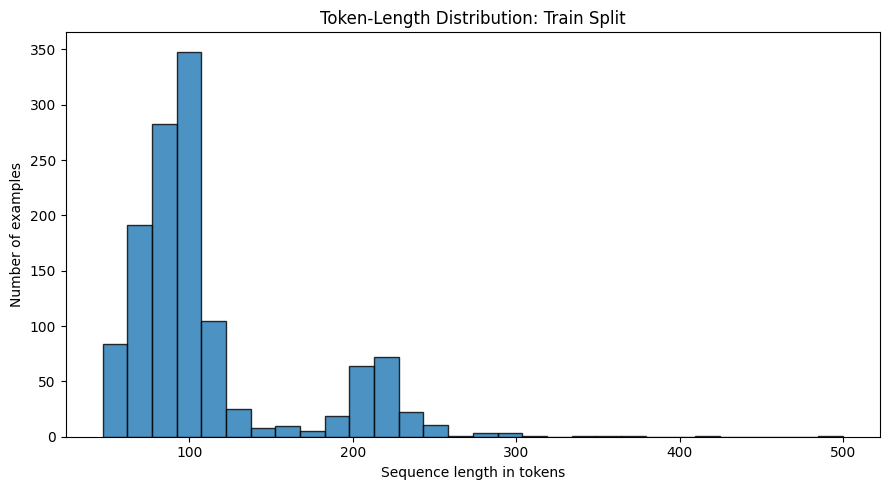

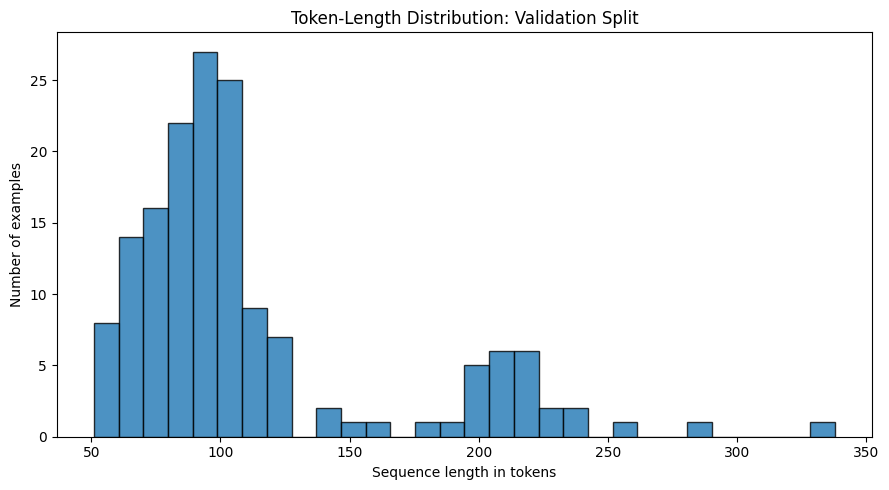

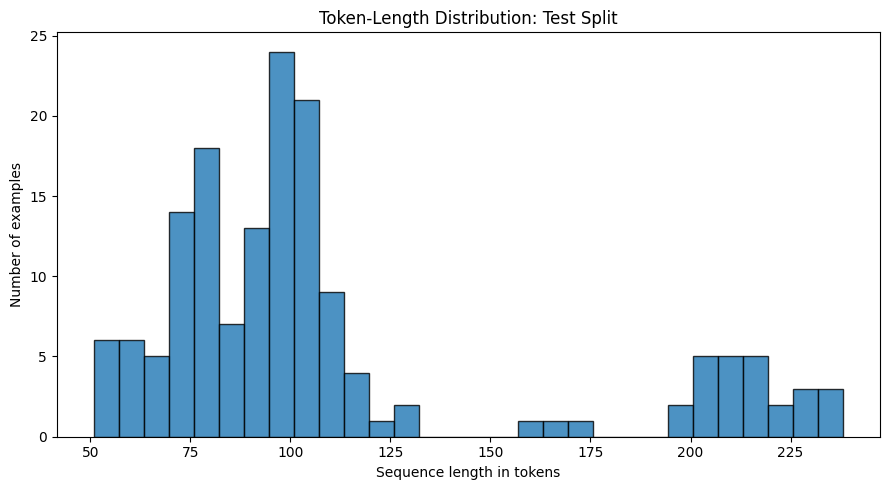

In [35]:
for split_name in [
    "train",
    "validation",
    "test",
]:
    split_lengths = length_df.loc[
        length_df["split"] == split_name,
        "token_length",
    ]

    plt.figure(figsize=(9, 5))

    plt.hist(
        split_lengths,
        bins=30,
        edgecolor="black",
        alpha=0.8,
    )

    plt.xlabel("Sequence length in tokens")
    plt.ylabel("Number of examples")
    plt.title(
        f"Token-Length Distribution: "
        f"{split_name.capitalize()} Split"
    )
    plt.tight_layout()
    plt.show()

## 6. Evaluate Candidate Context Lengths

Compare several possible context lengths and measure how many examples would be truncated at each value.

In [36]:
truncation_records = []

for max_length in CANDIDATE_LENGTHS:
    truncated_mask = (
        length_df["token_length"] > max_length
    )

    truncated_count = int(truncated_mask.sum())

    truncated_percentage = (
        truncated_count / len(length_df) * 100
    )

    retained_percentage = 100 - truncated_percentage

    truncation_records.append(
        {
            "max_length": max_length,
            "examples_truncated": truncated_count,
            "truncated_percentage": round(
                truncated_percentage,
                2,
            ),
            "retained_percentage": round(
                retained_percentage,
                2,
            ),
        }
    )

truncation_summary = pd.DataFrame(
    truncation_records
)

truncation_summary

,max_length,examples_truncated,truncated_percentage,retained_percentage
0,256,16,1.02,98.98
1,512,0,0.00,100.00
2,768,0,0.00,100.00
3,1024,0,0.00,100.00
4,1536,0,0.00,100.00
5,2048,0,0.00,100.00


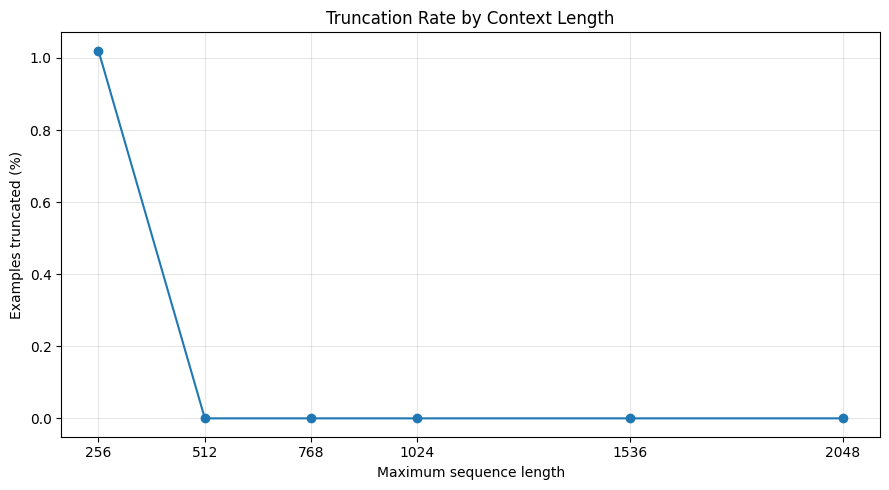

In [37]:
plt.figure(figsize=(9, 5))

plt.plot(
    truncation_summary["max_length"],
    truncation_summary["truncated_percentage"],
    marker="o",
)

plt.xlabel("Maximum sequence length")
plt.ylabel("Examples truncated (%)")
plt.title("Truncation Rate by Context Length")
plt.xticks(CANDIDATE_LENGTHS)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
split_truncation_records = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    split_lengths = length_df.loc[
        length_df["split"] == split_name,
        "token_length",
    ]

    for max_length in CANDIDATE_LENGTHS:
        truncated_count = int(
            (split_lengths > max_length).sum()
        )

        truncated_percentage = (
            truncated_count
            / len(split_lengths)
            * 100
        )

        split_truncation_records.append(
            {
                "split": split_name,
                "max_length": max_length,
                "examples_truncated": truncated_count,
                "truncated_percentage": round(
                    truncated_percentage,
                    2,
                ),
            }
        )

split_truncation_summary = pd.DataFrame(
    split_truncation_records
)

split_truncation_summary

,split,max_length,examples_truncated,truncated_percentage
0,train,256,13,1.03
1,train,512,0,0.00
2,train,768,0,0.00
3,train,1024,0,0.00
4,train,1536,0,0.00
5,train,2048,0,0.00
6,validation,256,3,1.90
7,validation,512,0,0.00
8,validation,768,0,0.00
9,validation,1024,0,0.00


In [39]:
split_truncation_table = (
    split_truncation_summary.pivot(
        index="max_length",
        columns="split",
        values="truncated_percentage",
    )
    .round(2)
)

split_truncation_table

split,test,train,validation
max_length,,,
256,0.0,1.03,1.9
512,0.0,0.00,0.0
768,0.0,0.00,0.0
1024,0.0,0.00,0.0
1536,0.0,0.00,0.0
2048,0.0,0.00,0.0


In [40]:
token_loss_records = []

for max_length in CANDIDATE_LENGTHS:
    excess_tokens = (
        length_df["token_length"]
        - max_length
    ).clip(lower=0)

    tokens_removed = int(excess_tokens.sum())

    total_tokens = int(
        length_df["token_length"].sum()
    )

    token_loss_percentage = (
        tokens_removed / total_tokens * 100
    )

    token_loss_records.append(
        {
            "max_length": max_length,
            "tokens_removed": tokens_removed,
            "token_loss_percentage": round(
                token_loss_percentage,
                2,
            ),
        }
    )

token_loss_summary = pd.DataFrame(
    token_loss_records
)

token_loss_summary

,max_length,tokens_removed,token_loss_percentage
0,256,1056,0.6
1,512,0,0.0
2,768,0,0.0
3,1024,0,0.0
4,1536,0,0.0
5,2048,0,0.0


In [41]:
context_length_summary = (
    truncation_summary.merge(
        token_loss_summary,
        on="max_length",
    )
)

context_length_summary

,max_length,examples_truncated,truncated_percentage,retained_percentage,tokens_removed,token_loss_percentage
0,256,16,1.02,98.98,1056,0.6
1,512,0,0.00,100.00,0,0.0
2,768,0,0.00,100.00,0,0.0
3,1024,0,0.00,100.00,0,0.0
4,1536,0,0.00,100.00,0,0.0
5,2048,0,0.00,100.00,0,0.0


## 7. Select the Training Context Length

Select the final sequence length based on the truncation analysis and training efficiency.

In [42]:
MAX_SEQ_LENGTH = 512

selected_result = context_length_summary.loc[
    context_length_summary["max_length"] == MAX_SEQ_LENGTH
].iloc[0]

print("=" * 60)
print("FINAL CONTEXT-LENGTH SELECTION")
print("=" * 60)

print(f"Selected MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}")
print(
    f"Examples truncated: "
    f"{int(selected_result['examples_truncated'])}"
)
print(
    f"Truncated percentage: "
    f"{selected_result['truncated_percentage']:.2f}%"
)
print(
    f"Total token loss: "
    f"{selected_result['token_loss_percentage']:.2f}%"
)

FINAL CONTEXT-LENGTH SELECTION
Selected MAX_SEQ_LENGTH: 512
Examples truncated: 0
Truncated percentage: 0.00%
Total token loss: 0.00%


### Final decision

`MAX_SEQ_LENGTH = 512` was selected for fine-tuning. Although 256 tokens covers approximately 99% of the dataset, 512 tokens provides additional capacity for longer scientific explanations and code-generation responses while remaining computationally efficient.

In [43]:
MAX_SEQ_LENGTH = 512